# Trees, Bagging, and Random Forests

Part 1 implements a classification stump and bootstrap aggregation from
scratch. Part 2 reproduces every data-driven figure in the lecture slides, so
each plot shown in class can be rerun and changed here.

## Part 1 --- from scratch

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, log_loss

SEED = 26515
rng = np.random.default_rng(SEED)
oj = pd.read_csv('OJ.csv')
oj[['Purchase', 'WeekofPurchase', 'LoyalCH', 'PriceDiff']].head()

,Purchase,WeekofPurchase,LoyalCH,PriceDiff
0,CH,237,0.500000,0.24
1,CH,239,0.600000,-0.06
2,CH,245,0.680000,0.40
3,MM,227,0.400000,0.00
4,CH,228,0.956535,0.00


### The chronological split, and a Gini scan written out by hand

In [2]:
y = (oj.Purchase == 'CH').astype(int).to_numpy()
train = oj.WeekofPurchase.to_numpy() <= 260
valid = (oj.WeekofPurchase.to_numpy() > 260) & (oj.WeekofPurchase.to_numpy() <= 266)
test = oj.WeekofPurchase.to_numpy() > 266
print(f'train={train.sum()}  valid={valid.sum()}  test={test.sum()}')

def gini(labels):
    if len(labels) == 0:
        return 0.0
    p = np.mean(labels)
    return 1 - p ** 2 - (1 - p) ** 2

def best_stump(feature, labels):
    values = np.sort(np.unique(feature))
    thresholds = (values[:-1] + values[1:]) / 2
    parent = gini(labels)
    best = (None, -np.inf)
    for threshold in thresholds:
        is_left = feature <= threshold
        if is_left.sum() == 0 or is_left.sum() == len(labels):
            continue
        child = is_left.mean() * gini(labels[is_left]) + (1 - is_left.mean()) * gini(labels[~is_left])
        if parent - child > best[1]:
            best = (threshold, parent - child)
    return best

threshold, gain = best_stump(oj.loc[train, 'LoyalCH'].to_numpy(), y[train])
print(f'best root split: LoyalCH <= {threshold:.3f} with Gini gain {gain:.3f}')

train=629  valid=138  test=303
best root split: LoyalCH <= 0.483 with Gini gain 0.182


### Bootstrap aggregation, also by hand\n\nEach bootstrap sample fits a new LoyalCH stump; averaging their probabilities gives a small bagged model.

In [3]:
def stump_predict(feature, threshold, left_probability, right_probability):
    return np.where(feature <= threshold, left_probability, right_probability)

def fit_stump(feature, labels):
    threshold, _ = best_stump(feature, labels)
    is_left = feature <= threshold
    return threshold, labels[is_left].mean(), labels[~is_left].mean()

train_rows = np.flatnonzero(train)
loyalty_test = oj.loc[test, 'LoyalCH'].to_numpy()
fitted_stumps, bagged = [], []
for _ in range(100):
    bootstrap = rng.choice(train_rows, size=len(train_rows), replace=True)
    fitted = fit_stump(oj.loc[bootstrap, 'LoyalCH'].to_numpy(), y[bootstrap])
    fitted_stumps.append(fitted)
    bagged.append(stump_predict(loyalty_test, *fitted))
bagged_probability = np.mean(bagged, axis=0)
single = stump_predict(loyalty_test, *fit_stump(oj.loc[train, 'LoyalCH'].to_numpy(), y[train]))
print(f'single stump : accuracy {accuracy_score(y[test], single >= .5):.3f}   log loss {log_loss(y[test], single):.3f}')
print(f'bagged stumps: accuracy {accuracy_score(y[test], bagged_probability >= .5):.3f}   log loss {log_loss(y[test], bagged_probability):.3f}')

single stump : accuracy 0.789   log loss 0.513
bagged stumps: accuracy 0.785   log loss 0.507


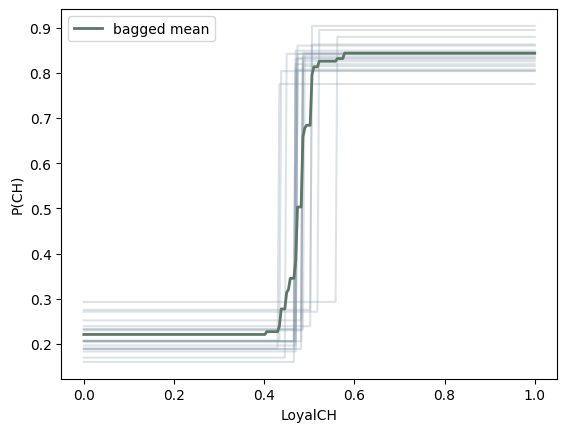

In [4]:
grid = np.linspace(0, 1, 250)
curves = np.array([stump_predict(grid, *fitted) for fitted in fitted_stumps])
for curve in curves[:20]:
    plt.plot(grid, curve, color='#7B8FA3', alpha=.25)
plt.plot(grid, curves.mean(0), color='#5B7864', linewidth=2, label='bagged mean')
plt.xlabel('LoyalCH'); plt.ylabel('P(CH)'); plt.legend(); plt.show()

## Part 2 --- every figure in the slides

The cells below are the figure code used to make the slides, with the file
write replaced by an inline plot.

In [5]:
import matplotlib as mpl
from matplotlib.patches import FancyBboxPatch
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# course palette and figure sizes
BLUE, BLUE_BRIGHT, RED, GREEN = '#00356B', '#286DC0', '#7A3E47', '#5B7864'
INK, MUTED, RULE = '#202A35', '#66727E', '#D8E0E8'
BLUE_FILL, RED_FILL, GREEN_FILL = '#7B8FA3', '#A3838A', '#8FA394'
TEXTWIDTH = 5.63
FULL, FULL_TALL, FULL_SHORT = (TEXTWIDTH, 2.0), (TEXTWIDTH, 2.35), (TEXTWIDTH, 1.7)
HALF_TALL = (2.70, 2.45)
mpl.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.titlecolor': BLUE, 'axes.edgecolor': MUTED, 'xtick.color': MUTED,
                     'ytick.color': MUTED, 'legend.frameon': False, 'font.size': 9})

# the data set-up the figure script performs at import time.  Note y is a
# pandas Series here, exactly as in the figure script.
y = (oj['Purchase'] == 'CH').astype(int)
X_frame = pd.get_dummies(oj.drop(columns='Purchase'), drop_first=True, dtype=float)
feature_names = X_frame.columns.to_numpy()
X = X_frame.to_numpy(float)
train_mask, valid_mask, test_mask = train, valid, test
print(f'{X.shape[1]} features after encoding')

17 features after encoding


In [6]:
def gini(labels: np.ndarray) -> float:
    if len(labels) == 0:
        return 0.0
    probability = labels.mean()
    return 1 - probability ** 2 - (1 - probability) ** 2


def two_feature_data():
    columns = ["LoyalCH", "PriceDiff"]
    values = oj[columns].to_numpy(float)
    return values, columns


def draw_regions(ax, model, values, title):
    x1 = np.linspace(values[:, 0].min(), values[:, 0].max(), 220)
    x2 = np.linspace(values[:, 1].min(), values[:, 1].max(), 220)
    grid1, grid2 = np.meshgrid(x1, x2)
    probability = model.predict_proba(np.c_[grid1.ravel(), grid2.ravel()])[:, 1].reshape(grid1.shape)
    ax.contourf(grid1, grid2, probability, levels=np.linspace(0, 1, 11), cmap="RdBu", alpha=0.35)
    ax.contour(grid1, grid2, probability, levels=[0.5], colors=GREEN, linewidths=1.4)
    sample = rng.choice(len(values), size=min(350, len(values)), replace=False)
    ax.scatter(values[sample, 0], values[sample, 1], c=np.where(y.iloc[sample] == 1, BLUE, RED), s=7, alpha=0.5)
    ax.set(title=title, xlabel="LoyalCH")


def _fitted_tree_model():
    values, _ = two_feature_data()
    return DecisionTreeClassifier(max_depth=2, min_samples_leaf=35,
                                  random_state=SEED).fit(values[train_mask], y[train_mask])


def _draw_fitted_tree(path=(), figsize=(2.80, 1.95)):
    """Draw the depth-2 OJ tree; `path` names nodes to highlight."""
    from matplotlib.patches import FancyBboxPatch

    tree = _fitted_tree_model().tree_
    threshold = {i: tree.threshold[i] for i in range(tree.node_count) if tree.feature[i] >= 0}

    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    hot = set(path)

    def node(key, xy, label, face, edge, w, h=0.16, size=8.0):
        x, yy = xy
        live = key in hot
        ax.add_patch(FancyBboxPatch((x - w / 2, yy - h / 2), w, h,
                                    boxstyle="round,pad=0.012,rounding_size=0.03",
                                    facecolor="#F8F1F2" if live else face,
                                    edgecolor=RED if live else edge,
                                    linewidth=1.8 if live else 1.0))
        ax.text(x, yy, label, ha="center", va="center", fontsize=size,
                color=RED if live else "black")

    def link(a, b, label, dx, live=False):
        ax.plot([a[0], b[0]], [a[1] - 0.08, b[1] + 0.09],
                color=RED if live else MUTED, linewidth=1.8 if live else 1.0)
        ax.text((a[0] + b[0]) / 2 + dx, (a[1] + b[1]) / 2, label, fontsize=7.2,
                color=RED if live else MUTED, ha="center", va="center")

    root, left, right = (0.5, 0.90), (0.26, 0.54), (0.74, 0.54)
    leaves = [(0.10, 0.14), (0.37, 0.14), (0.63, 0.14), (0.90, 0.14)]
    node(0, root, f"LoyalCH $\\leq$ {threshold[0]:.2f}", "#F2F6FA", BLUE, 0.46)
    node(1, left, f"LoyalCH $\\leq$ {threshold[1]:.2f}", "#F2F6FA", BLUE, 0.44)
    node(4, right, f"LoyalCH $\\leq$ {threshold[4]:.2f}", "#F2F6FA", BLUE, 0.44)
    link(root, left, "yes", -0.06, 1 in hot); link(root, right, "no", 0.06, 4 in hot)
    link(left, leaves[0], "yes", -0.05, 2 in hot); link(left, leaves[1], "no", 0.05, 3 in hot)
    link(right, leaves[2], "yes", -0.05, 5 in hot); link(right, leaves[3], "no", 0.05, 6 in hot)
    for xy, i in zip(leaves, [2, 3, 5, 6]):
        counts = tree.value[i][0]
        node(i, xy, f"$\\widehat p={counts[1] / counts.sum():.2f}$\n$n={int(tree.n_node_samples[i])}$",
             "#F1F5F2", GREEN, 0.20, h=0.20)
    return fig, ax


def _boundary_panel(ax, model, points, labels, title):
    grid1, grid2 = np.meshgrid(np.linspace(0, 1, 260), np.linspace(0, 1, 260))
    predicted = model.predict(np.c_[grid1.ravel(), grid2.ravel()]).reshape(grid1.shape)
    ax.contourf(grid1, grid2, predicted, levels=[-0.5, 0.5, 1.5],
                colors=["#F8F1F2", "#F2F6FA"])
    ax.contour(grid1, grid2, predicted, levels=[0.5], colors=[GREEN], linewidths=1.4)
    ax.scatter(points[:, 0], points[:, 1], s=7, alpha=0.55,
               c=np.where(labels == 1, BLUE, RED))
    ax.set(xlim=(0, 1), ylim=(0, 1), xticks=[0, 0.5, 1], yticks=[0, 0.5, 1],
           xlabel="$x_1$", title=title)

### The data: loyalty against price difference

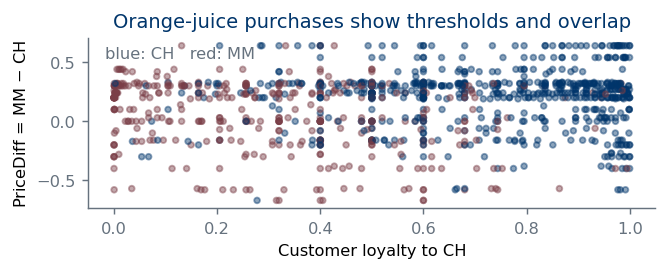

In [7]:
def save_oj_scatter() -> None:
    fig, ax = plt.subplots(figsize=FULL_SHORT)
    colors = np.where(y.to_numpy() == 1, BLUE, RED)
    ax.scatter(oj["LoyalCH"], oj["PriceDiff"], c=colors, s=10, alpha=0.45)
    ax.set(xlabel="Customer loyalty to CH", ylabel="PriceDiff = MM $-$ CH",
           title="Orange-juice purchases show thresholds and overlap")
    ax.text(0.03, 0.95, "blue: CH   red: MM", transform=ax.transAxes, color=MUTED, va="top")
    plt.show()

save_oj_scatter()

### The fitted depth-2 tree

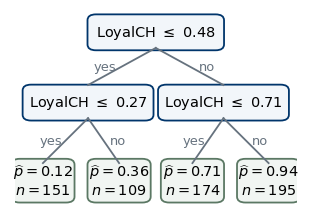

In [8]:
def save_fitted_tree() -> None:
    fig, _ = _draw_fitted_tree()
    plt.show()

save_fitted_tree()

### One shopping occasion, pushed through the tree

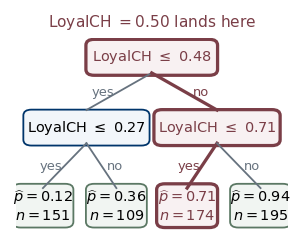

In [9]:
def save_fitted_tree_path() -> None:
    fig, ax = _draw_fitted_tree(path=(0, 4, 5), figsize=(2.70, 1.95))
    ax.set_title("LoyalCH $=0.50$ lands here", fontsize=8.5, color=RED)
    plt.show()

save_fitted_tree_path()

### The same tree, seen in the data plane

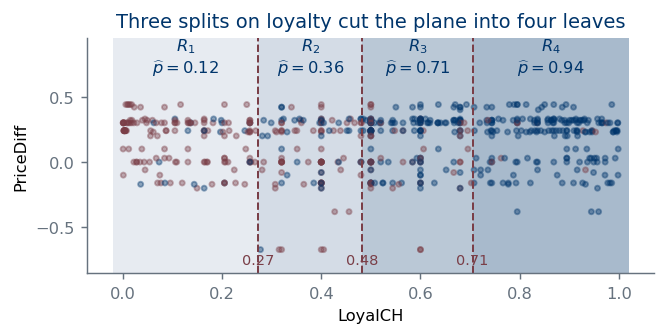

In [10]:
def save_tree_partition() -> None:
    """The fitted tree seen in the data plane: bands, split lines, leaf values."""
    values, _ = two_feature_data()
    model = _fitted_tree_model()
    tree = model.tree_
    cuts = sorted(tree.threshold[i] for i in range(tree.node_count) if tree.feature[i] >= 0)
    edges = [values[:, 0].min() - 0.02] + cuts + [values[:, 0].max() + 0.02]

    fig, ax = plt.subplots(figsize=FULL_TALL)
    labels = np.asarray(y)[train_mask]
    points = values[train_mask]
    for k in range(len(edges) - 1):
        inside = (points[:, 0] > edges[k]) & (points[:, 0] <= edges[k + 1])
        probability = labels[inside].mean()
        ax.axvspan(edges[k], edges[k + 1], color=BLUE, alpha=0.06 + 0.30 * probability, lw=0)
        ax.text((edges[k] + edges[k + 1]) / 2, 0.80,
                f"$R_{k + 1}$\n$\\widehat p={probability:.2f}$",
                ha="center", va="center", fontsize=9, color=BLUE)
    for cut in cuts:
        ax.axvline(cut, color=RED, linestyle="--", linewidth=1.1)
        ax.text(cut, -0.80, f"{cut:.2f}", ha="center", va="bottom", fontsize=8, color=RED)
    ax.scatter(points[:, 0], points[:, 1], s=8, alpha=0.4,
               c=np.where(labels == 1, BLUE, RED))
    ax.set(xlabel="LoyalCH", ylabel="PriceDiff", ylim=(-0.85, 0.95),
           title="Three splits on loyalty cut the plane into four leaves")
    plt.show()

save_tree_partition()

### Where the best cut sits, on twenty points

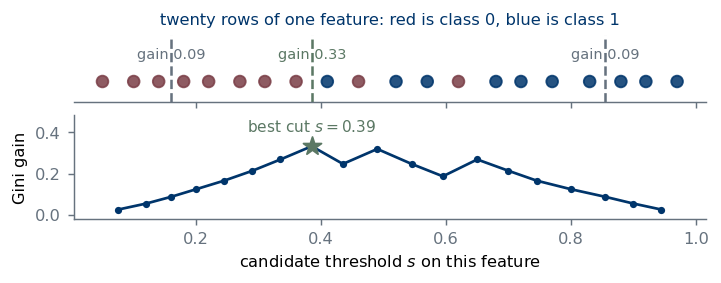

In [11]:
def save_split_sweet_spot() -> None:
    """Twenty points on one feature: which cut, and how good is it?"""
    x = np.array([.05, .10, .14, .18, .22, .27, .31, .36, .41, .46,
                  .52, .57, .62, .68, .72, .77, .83, .88, .92, .97])
    labels = (x > 0.5).astype(int)
    labels[8] = 1      # one blue point sitting on the red side
    labels[12] = 0     # one red point sitting on the blue side

    candidates = (x[:-1] + x[1:]) / 2
    parent = gini(labels)
    gains = np.array([parent - (len(labels[x <= c]) * gini(labels[x <= c])
                                + len(labels[x > c]) * gini(labels[x > c])) / len(labels)
                      for c in candidates])
    best = int(np.argmax(gains))
    marks = [2, best, 16]

    fig, axes = plt.subplots(2, 1, figsize=(TEXTWIDTH, 2.25),
                             gridspec_kw={"height_ratios": [1, 1.55]}, sharex=True)

    ax = axes[0]
    ax.scatter(x, np.zeros_like(x), c=np.where(labels == 1, BLUE, RED), s=42,
               alpha=0.85, zorder=3)
    for k in marks:
        colour = GREEN if k == best else MUTED
        ax.axvline(candidates[k], color=colour, linestyle="--", linewidth=1.4)
        ax.text(candidates[k], 0.55, f"gain {gains[k]:.2f}", ha="center",
                fontsize=8, color=colour)
    ax.set(ylim=(-0.5, 1.1), yticks=[])
    ax.spines["left"].set_visible(False)
    ax.set_title("twenty rows of one feature: red is class 0, blue is class 1",
                 fontsize=9)

    ax = axes[1]
    ax.plot(candidates, gains, color=BLUE, marker="o", ms=3)
    ax.scatter([candidates[best]], [gains[best]], color=GREEN, marker="*", s=110, zorder=5)
    ax.annotate(f"best cut $s={candidates[best]:.2f}$", (candidates[best], gains[best]),
                textcoords="offset points", xytext=(0, 8), ha="center",
                fontsize=8.5, color=GREEN)
    ax.set(xlabel="candidate threshold $s$ on this feature", ylabel="Gini gain",
           ylim=(-0.02, gains.max() * 1.45))
    fig.tight_layout(h_pad=0.4)
    plt.show()

save_split_sweet_spot()

### Scanning every feature and every threshold

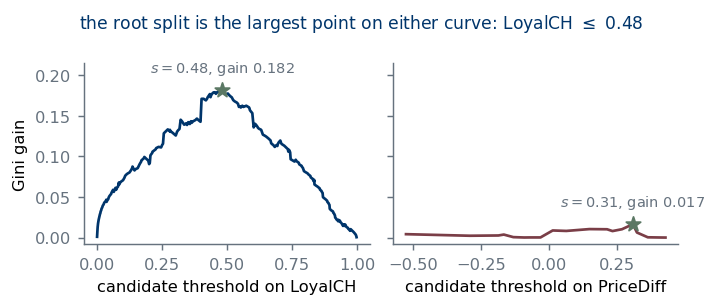

In [12]:
def save_split_search() -> None:
    """Every feature, every observed threshold: the whole root-node search."""
    values, columns = two_feature_data()
    points, labels = values[train_mask], np.asarray(y)[train_mask]
    parent = gini(labels)

    fig, axes = plt.subplots(1, 2, figsize=FULL_TALL, sharey=True)
    best = (None, None, -1.0)
    for ax, column, name, color in zip(axes, range(2), columns, [BLUE, RED]):
        feature = points[:, column]
        candidates = np.unique(feature)
        candidates = (candidates[:-1] + candidates[1:]) / 2
        gains = []
        for threshold in candidates:
            left, right = labels[feature <= threshold], labels[feature > threshold]
            gains.append(parent - (len(left) * gini(left) + len(right) * gini(right)) / len(labels))
        gains = np.asarray(gains)
        top = int(np.argmax(gains))
        if gains[top] > best[2]:
            best = (name, candidates[top], gains[top])
        ax.plot(candidates, gains, color=color)
        ax.scatter([candidates[top]], [gains[top]], color=GREEN, marker="*", s=70, zorder=5)
        ax.annotate(f"$s={candidates[top]:.2f}$, gain ${gains[top]:.3f}$",
                    (candidates[top], gains[top]), textcoords="offset points",
                    xytext=(0, 10), ha="center", fontsize=8, color=MUTED,
                    annotation_clip=False)
        ax.set(xlabel=f"candidate threshold on {name}", ylim=(-0.008, 0.215))
    axes[0].set_ylabel("Gini gain")
    fig.suptitle(f"the root split is the largest point on either curve: {best[0]} $\\leq$ {best[1]:.2f}",
                 fontsize=9.5, color=BLUE)
    fig.tight_layout(w_pad=0.6)
    plt.show()

save_split_search()

### Growth, one split at a time

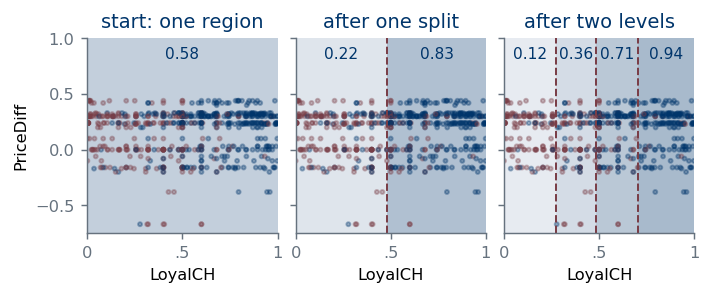

In [13]:
def save_tree_growth_steps() -> None:
    """One region, then two, then four: greedy growth on the OJ training weeks."""
    values, _ = two_feature_data()
    points, labels = values[train_mask], np.asarray(y)[train_mask]

    fig, axes = plt.subplots(1, 3, figsize=FULL_TALL, sharey=True)
    for ax, depth, title in zip(axes, [0, 1, 2],
                                ["start: one region", "after one split", "after two levels"]):
        if depth == 0:
            cuts = []
        else:
            model = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=35,
                                           random_state=SEED).fit(points, labels)
            cuts = sorted(model.tree_.threshold[i] for i in range(model.tree_.node_count)
                          if model.tree_.feature[i] >= 0)
        edges = [0.0] + list(cuts) + [1.0]
        for k in range(len(edges) - 1):
            inside = (points[:, 0] > edges[k]) & (points[:, 0] <= edges[k + 1])
            probability = labels[inside].mean() if inside.any() else 0.5
            ax.axvspan(edges[k], edges[k + 1], color=BLUE, alpha=0.06 + 0.30 * probability, lw=0)
            ax.text((edges[k] + edges[k + 1]) / 2, 0.86, f"{probability:.2f}",
                    ha="center", va="center", fontsize=8.5, color=BLUE)
        for cut in cuts:
            ax.axvline(cut, color=RED, linestyle="--", linewidth=1.1)
        ax.scatter(points[:, 0], points[:, 1], s=5, alpha=0.35,
                   c=np.where(labels == 1, BLUE, RED))
        ax.set(xlim=(0, 1), ylim=(-0.75, 1.0), xlabel="LoyalCH", title=title,
               xticks=[0, 0.5, 1], xticklabels=["0", ".5", "1"])
    axes[0].set_ylabel("PriceDiff")
    fig.tight_layout(w_pad=0.4)
    plt.show()

save_tree_growth_steps()

### The price and the gain of axis-aligned boxes

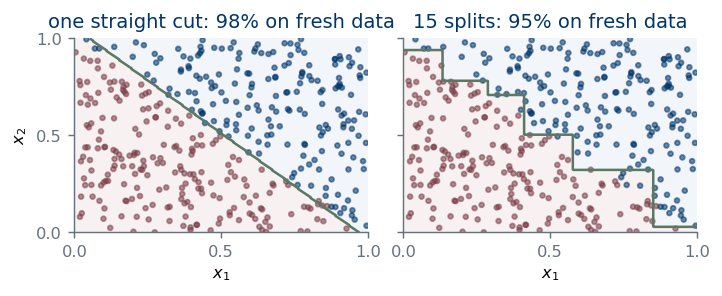

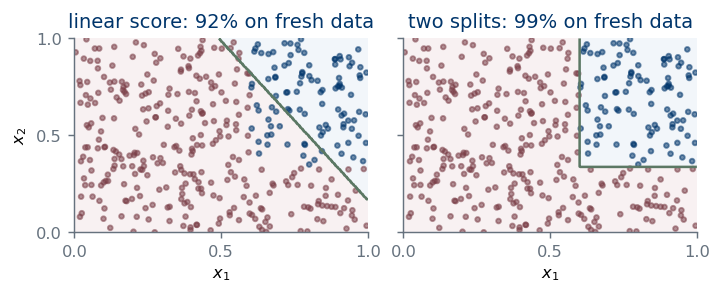

In [14]:
def save_tree_price_and_gain() -> None:
    """Two simulated problems: one an axis-aligned tree handles badly, one well."""
    local = np.random.default_rng(SEED)
    points = local.uniform(0, 1, size=(400, 2))
    fresh = local.uniform(0, 1, size=(4000, 2))

    # Price: the truth is an oblique boundary.
    oblique = (points[:, 0] + points[:, 1] > 1).astype(int)
    linear = LogisticRegression().fit(points, oblique)
    deep = DecisionTreeClassifier(max_depth=4, random_state=SEED).fit(points, oblique)
    fig, axes = plt.subplots(1, 2, figsize=FULL_TALL, sharey=True)
    oblique_fresh = (fresh[:, 0] + fresh[:, 1] > 1).astype(int)
    _boundary_panel(axes[0], linear, points, oblique,
                    f"one straight cut: {accuracy_score(oblique_fresh, linear.predict(fresh)):.0%} on fresh data")
    _boundary_panel(axes[1], deep, points, oblique,
                    f"15 splits: {accuracy_score(oblique_fresh, deep.predict(fresh)):.0%} on fresh data")
    axes[0].set_ylabel("$x_2$")
    fig.tight_layout(w_pad=0.6)
    plt.show()

    # Gain: the response turns on only where both features clear a threshold.
    interaction = ((points[:, 0] > 0.6) & (points[:, 1] > 0.35)).astype(int)
    linear = LogisticRegression().fit(points, interaction)
    stump = DecisionTreeClassifier(max_depth=2, random_state=SEED).fit(points, interaction)
    fig, axes = plt.subplots(1, 2, figsize=FULL_TALL, sharey=True)
    interaction_fresh = ((fresh[:, 0] > 0.6) & (fresh[:, 1] > 0.35)).astype(int)
    _boundary_panel(axes[0], linear, points, interaction,
                    f"linear score: {accuracy_score(interaction_fresh, linear.predict(fresh)):.0%} on fresh data")
    _boundary_panel(axes[1], stump, points, interaction,
                    f"two splits: {accuracy_score(interaction_fresh, stump.predict(fresh)):.0%} on fresh data")
    axes[0].set_ylabel("$x_2$")
    fig.tight_layout(w_pad=0.6)
    plt.show()

save_tree_price_and_gain()

### Depth and partition complexity

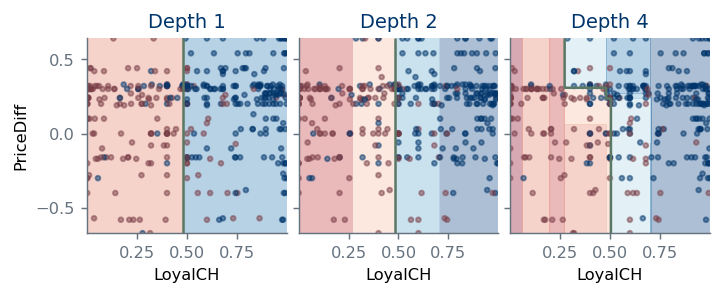

In [15]:
def save_depth_regions() -> None:
    values, _ = two_feature_data()
    fig, axes = plt.subplots(1, 3, figsize=FULL_TALL, sharex=True, sharey=True)
    for ax, depth in zip(axes, [1, 2, 4]):
        model = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=18, random_state=SEED).fit(values[train_mask], y[train_mask])
        draw_regions(ax, model, values, f"Depth {depth}")
    axes[0].set_ylabel("PriceDiff")
    fig.tight_layout(w_pad=0.35)
    plt.show()

save_depth_regions()

### The cost-complexity pruning path

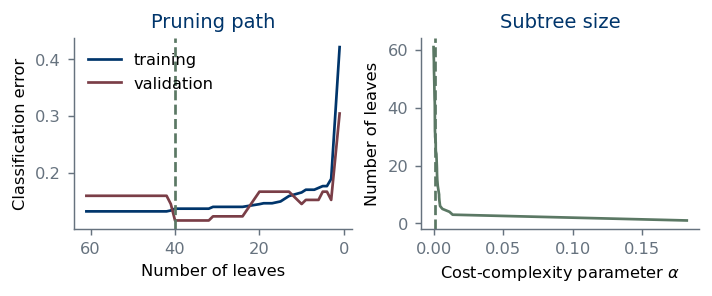

In [16]:
def save_pruning() -> None:
    base = DecisionTreeClassifier(min_samples_leaf=5, random_state=SEED)
    path = base.cost_complexity_pruning_path(X[train_mask], y[train_mask])
    positive = np.unique(path.ccp_alphas[path.ccp_alphas >= 0])
    indices = np.unique(np.linspace(0, len(positive) - 1, min(35, len(positive))).astype(int))
    alphas = positive[indices]
    train_error, valid_error, leaves = [], [], []
    for alpha in alphas:
        model = DecisionTreeClassifier(min_samples_leaf=5, ccp_alpha=float(alpha), random_state=SEED).fit(X[train_mask], y[train_mask])
        train_error.append(1 - model.score(X[train_mask], y[train_mask]))
        valid_error.append(1 - model.score(X[valid_mask], y[valid_mask]))
        leaves.append(model.get_n_leaves())
    best = int(np.argmin(valid_error))
    fig, axes = plt.subplots(1, 2, figsize=FULL_TALL)
    axes[0].plot(leaves, train_error, color=BLUE, label="training")
    axes[0].plot(leaves, valid_error, color=RED, label="validation")
    axes[0].axvline(leaves[best], color=GREEN, linestyle="--")
    axes[0].invert_xaxis()
    axes[0].set(xlabel="Number of leaves", ylabel="Classification error", title="Pruning path")
    axes[0].legend()
    axes[1].plot(alphas, leaves, color=GREEN)
    axes[1].axvline(alphas[best], color=GREEN, linestyle="--")
    axes[1].set(xlabel="Cost-complexity parameter $\\alpha$", ylabel="Number of leaves", title="Subtree size")
    fig.tight_layout(w_pad=0.8)
    plt.show()

save_pruning()

### The same procedure on two halves of the data

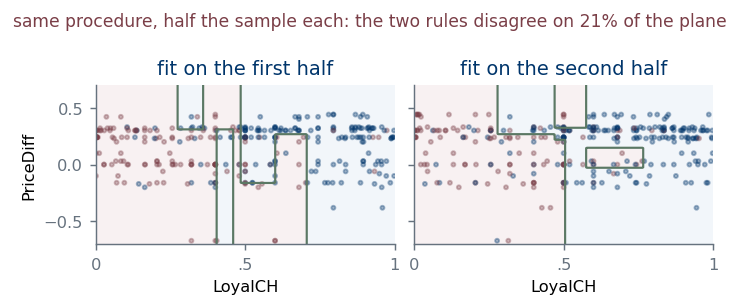

In [17]:
def save_tree_instability() -> None:
    """The same procedure on two halves of the same training weeks."""
    values, _ = two_feature_data()
    points, labels = values[train_mask], np.asarray(y)[train_mask]
    local = np.random.default_rng(SEED)
    order = local.permutation(len(points))
    halves = [order[: len(order) // 2], order[len(order) // 2:]]

    grid1, grid2 = np.meshgrid(np.linspace(0, 1, 200), np.linspace(-0.7, 0.7, 200))
    grid = np.c_[grid1.ravel(), grid2.ravel()]
    fits, predictions = [], []
    for half in halves:
        model = DecisionTreeClassifier(max_depth=5, min_samples_leaf=5,
                                       random_state=SEED).fit(points[half], labels[half])
        fits.append(model)
        predictions.append(model.predict(grid))
    disagreement = (predictions[0] != predictions[1]).mean()

    fig, axes = plt.subplots(1, 2, figsize=FULL_TALL, sharey=True)
    for ax, model, half, name in zip(axes, fits, halves, ["first half", "second half"]):
        predicted = model.predict(grid).reshape(grid1.shape)
        ax.contourf(grid1, grid2, predicted, levels=[-0.5, 0.5, 1.5], colors=["#F8F1F2", "#F2F6FA"])
        ax.contour(grid1, grid2, predicted, levels=[0.5], colors=[GREEN], linewidths=1.2)
        ax.scatter(points[half, 0], points[half, 1], s=5, alpha=0.35,
                   c=np.where(labels[half] == 1, BLUE, RED))
        ax.set(xlim=(0, 1), ylim=(-0.7, 0.7), xlabel="LoyalCH", title=f"fit on the {name}",
               xticks=[0, 0.5, 1], xticklabels=["0", ".5", "1"])
    axes[0].set_ylabel("PriceDiff")
    fig.suptitle(f"same procedure, half the sample each: the two rules disagree on "
                 f"{disagreement:.0%} of the plane", fontsize=9.5, color=RED)
    fig.tight_layout(w_pad=0.5)
    plt.show()

save_tree_instability()

### Bootstrap trees and their average

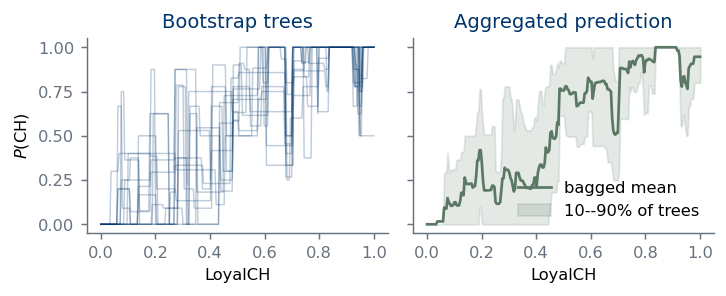

In [18]:
def save_bagging() -> None:
    values, _ = two_feature_data()
    loyalty = np.linspace(0, 1, 240)
    price_difference = float(oj.loc[train_mask, "PriceDiff"].median())
    grid = np.c_[loyalty, np.full_like(loyalty, price_difference)]
    predictions = []
    train_indices = np.flatnonzero(train_mask)
    for index in range(40):
        bootstrap = rng.choice(train_indices, size=len(train_indices), replace=True)
        tree = DecisionTreeClassifier(min_samples_leaf=8, random_state=SEED + index).fit(values[bootstrap], y.iloc[bootstrap])
        predictions.append(tree.predict_proba(grid)[:, 1])
    predictions = np.asarray(predictions)
    fig, axes = plt.subplots(1, 2, figsize=FULL_TALL, sharey=True)
    for curve in predictions[:12]:
        axes[0].plot(loyalty, curve, color=BLUE, alpha=0.25, linewidth=0.8)
    axes[0].set(title="Bootstrap trees", xlabel="LoyalCH", ylabel="$P(\\mathrm{CH})$")
    axes[1].plot(loyalty, predictions.mean(axis=0), color=GREEN, label="bagged mean")
    axes[1].fill_between(loyalty, np.quantile(predictions, 0.1, axis=0), np.quantile(predictions, 0.9, axis=0),
                         color=GREEN, alpha=0.16, label="10--90% of trees")
    axes[1].set(title="Aggregated prediction", xlabel="LoyalCH")
    axes[1].legend()
    fig.tight_layout(w_pad=0.8)
    plt.show()

save_bagging()

### Bagging against a random forest

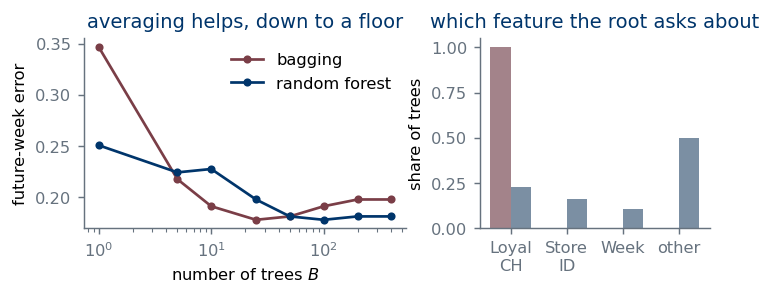

{'bagging': [0.347, 0.218, 0.191, 0.178, 0.182, 0.191, 0.198, 0.198], 'random forest': [0.251, 0.224, 0.228, 0.198, 0.182, 0.178, 0.182, 0.182]}
{'bagging': {np.str_('LoyalCH'): np.float64(1.0)}, 'random forest': {np.str_('ListPriceDiff'): np.float64(0.11), np.str_('LoyalCH'): np.float64(0.23), np.str_('PriceDiff'): np.float64(0.07), np.str_('PriceMM'): np.float64(0.06), np.str_('STORE'): np.float64(0.09), np.str_('SalePriceMM'): np.float64(0.06), np.str_('Store7_Yes'): np.float64(0.06), np.str_('StoreID'): np.float64(0.16), np.str_('WeekofPurchase'): np.float64(0.1)}}


In [19]:
def save_bagging_vs_forest() -> None:
    """Bagging against a random forest: error against B, and root-split diversity."""
    train_x, train_y = X[train_mask], y[train_mask]
    test_x, test_y = X[test_mask], y[test_mask]
    sizes = [1, 5, 10, 25, 50, 100, 200, 400]

    curves, roots = {}, {}
    for name, features in [("bagging", None), ("random forest", "sqrt")]:
        model = RandomForestClassifier(n_estimators=1, max_features=features,
                                       bootstrap=True, warm_start=True, random_state=SEED)
        errors = []
        for size in sizes:
            model.set_params(n_estimators=size).fit(train_x, train_y)
            errors.append(1 - accuracy_score(test_y, model.predict(test_x)))
        curves[name] = errors
        chosen = [feature_names[tree.tree_.feature[0]] for tree in model.estimators_]
        labels, counts = np.unique(chosen, return_counts=True)
        roots[name] = dict(zip(labels, counts / len(chosen)))

    fig, axes = plt.subplots(1, 2, figsize=FULL_TALL,
                             gridspec_kw={"width_ratios": [1.4, 1]})
    for (name, errors), colour in zip(curves.items(), [RED, BLUE]):
        axes[0].plot(sizes, errors, "o-", color=colour, ms=3.5, label=name)
    axes[0].set(xscale="log", xlabel="number of trees $B$", ylabel="future-week error",
                title="averaging helps, down to a floor")
    axes[0].legend(loc="upper right")

    top = ["LoyalCH", "StoreID", "WeekofPurchase", "other"]
    width = 0.36
    for k, (name, colour) in enumerate(zip(roots, [RED_FILL, BLUE_FILL])):
        share = roots[name]
        heights = [share.get(t, 0.0) for t in top[:-1]]
        heights.append(max(0.0, 1 - sum(heights)))
        axes[1].bar(np.arange(len(top)) + (k - 0.5) * width, heights, width=width,
                    color=colour, label=name)
    axes[1].set(xticks=np.arange(len(top)),
                xticklabels=["Loyal\nCH", "Store\nID", "Week", "other"],
                ylabel="share of trees", ylim=(0, 1.05),
                title="which feature the root asks about")
    fig.tight_layout(w_pad=0.8)
    plt.show()
    print({k: [round(e, 3) for e in v] for k, v in curves.items()})
    print({k: {a: round(b, 2) for a, b in v.items() if b > 0.05} for k, v in roots.items()})

save_bagging_vs_forest()

### Two feature-importance measures

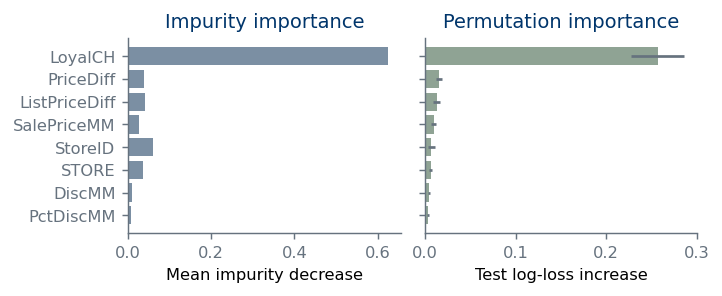

In [20]:
def save_importance() -> None:
    forest = RandomForestClassifier(n_estimators=400, min_samples_leaf=4, max_features="sqrt",
                                    random_state=SEED, n_jobs=-1).fit(X[train_mask], y[train_mask])
    permutation = permutation_importance(forest, X[test_mask], y[test_mask], n_repeats=20,
                                         random_state=SEED, scoring="neg_log_loss", n_jobs=-1)
    ranking = np.argsort(permutation.importances_mean)[-8:]
    positions = np.arange(len(ranking))
    fig, axes = plt.subplots(1, 2, figsize=FULL_TALL, sharey=True)
    axes[0].barh(positions, forest.feature_importances_[ranking], color=BLUE_FILL)
    axes[0].set(xlabel="Mean impurity decrease", title="Impurity importance")
    axes[1].barh(positions, permutation.importances_mean[ranking], color=GREEN_FILL,
                 xerr=permutation.importances_std[ranking], ecolor=MUTED)
    axes[1].set(xlabel="Test log-loss increase", title="Permutation importance")
    axes[0].set_yticks(positions, feature_names[ranking])
    fig.tight_layout(w_pad=0.7)
    plt.show()

save_importance()

### Four methods on the future weeks

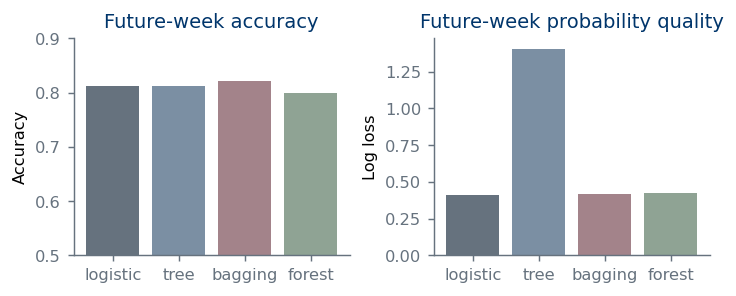

{'logistic': (0.8118811881188119, 0.41374790040954723), 'tree': (0.8118811881188119, 1.4063570127577643), 'bagging': (0.8217821782178217, 0.41718194263606617), 'forest': (0.7986798679867987, 0.42556052092098906)}


In [21]:
def save_model_comparison() -> None:
    models = {
        "logistic": make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
        "tree": DecisionTreeClassifier(max_depth=4, min_samples_leaf=18, random_state=SEED),
        "bagging": RandomForestClassifier(n_estimators=400, min_samples_leaf=4, max_features=None, random_state=SEED, n_jobs=-1),
        "forest": RandomForestClassifier(n_estimators=400, min_samples_leaf=4, max_features="sqrt", random_state=SEED, n_jobs=-1),
    }
    names, accuracy, losses = [], [], []
    for name, model in models.items():
        model.fit(X[train_mask], y[train_mask])
        probability = model.predict_proba(X[test_mask])[:, 1]
        names.append(name)
        accuracy.append(accuracy_score(y[test_mask], probability >= 0.5))
        losses.append(log_loss(y[test_mask], probability))
    positions = np.arange(len(names))
    fig, axes = plt.subplots(1, 2, figsize=FULL_TALL)
    axes[0].bar(positions, accuracy, color=[MUTED, BLUE_FILL, RED_FILL, GREEN_FILL])
    axes[0].set(xticks=positions, xticklabels=names, ylabel="Accuracy", ylim=(0.5, 0.9), title="Future-week accuracy")
    axes[1].bar(positions, losses, color=[MUTED, BLUE_FILL, RED_FILL, GREEN_FILL])
    axes[1].set(xticks=positions, xticklabels=names, ylabel="Log loss", title="Future-week probability quality")
    fig.tight_layout(w_pad=0.8)
    plt.show()
    print(dict(zip(names, zip(accuracy, losses))))

save_model_comparison()